Phase 2 — EDA on the cleaned 3-city restaurant data. Walks through 11 questions covering rating distribution, user/item sparsity, cuisine vocabulary, geographic clustering, hour-of-day patterns, cold-start ratios, review length, cross-city mobility, popularity bias, and activity-text availability. Produces 9 figures and writes the 50-cuisine vocabulary used by Phase 3 feature engineering.

In [1]:
import json
import logging
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

logging.basicConfig(level=logging.INFO,
                    format="%(asctime)s | %(message)s",
                    datefmt="%H:%M:%S",
                    force=True)
log = logging.getLogger(__name__)

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
CLEANED_DIR = PROJECT_ROOT / "data" / "cleaned"
FEATURES_DIR = PROJECT_ROOT / "data" / "features"
FIGURES_DIR = PROJECT_ROOT / "reports" / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
FEATURES_DIR.mkdir(parents=True, exist_ok=True)

plt.rcParams.update({"figure.dpi": 120, "savefig.dpi": 200, "font.size": 10})

restaurants = pd.read_parquet(CLEANED_DIR / "restaurants_open.parquet")
reviews = pd.read_parquet(CLEANED_DIR / "reviews_restaurant.parquet")
users = pd.read_parquet(CLEANED_DIR / "users_target.parquet")
print(f"restaurants={len(restaurants)} reviews={len(reviews)} users={len(users)}")

restaurants=9022 reviews=1032056 users=359007


**Q1 — rating distribution and user activity power-law.** Restaurant reviews on Yelp tend to be J-shaped (positive-skewed), and user review counts usually follow a Zipf-like long tail. I want to confirm both for our subset before deciding on positive/negative thresholds.

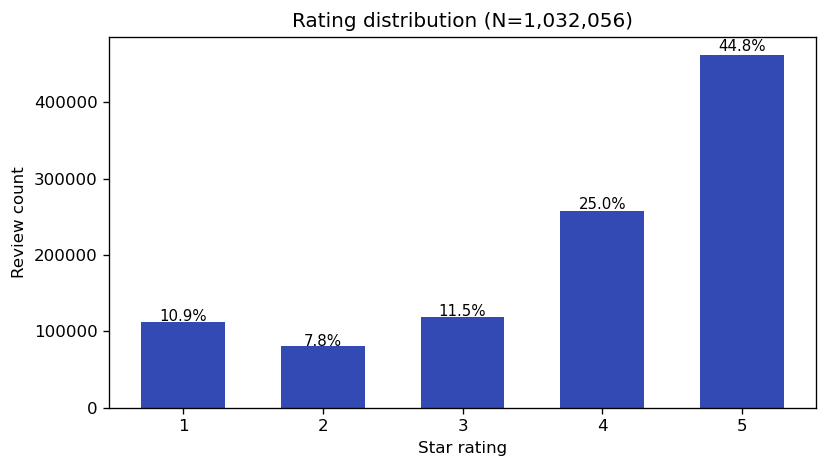

4-5 star share: 69.8%


In [2]:
# Q1a — rating histogram
fig, ax = plt.subplots(figsize=(7, 4))
rating_counts = reviews["stars"].value_counts().sort_index()
ax.bar(rating_counts.index, rating_counts.values, color="#3349B3", width=0.6)
ax.set_xlabel("Star rating")
ax.set_ylabel("Review count")
ax.set_title(f"Rating distribution (N={len(reviews):,})")
for x, y in zip(rating_counts.index, rating_counts.values):
    ax.text(x, y * 1.01, f"{y / len(reviews) * 100:.1f}%", ha="center", fontsize=9)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "eda_q1_rating_dist.png", bbox_inches="tight")
plt.show()

j_share = (rating_counts[4.0] + rating_counts[5.0]) / len(reviews)
print(f"4-5 star share: {j_share*100:.1f}%")

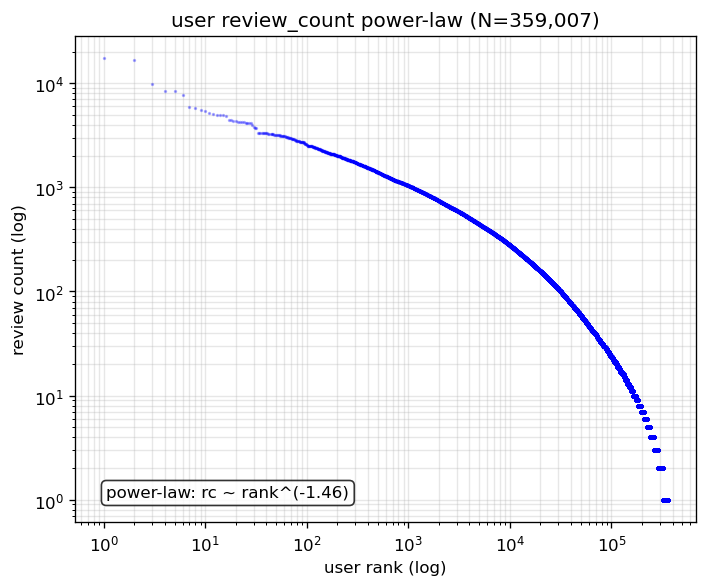

power-law exponent alpha = 1.46


In [3]:
# Q1b — user review_count power-law
user_rc = users["review_count"].values
rc_sorted = np.sort(user_rc)[::-1]
rank = np.arange(1, len(rc_sorted) + 1)

fig, ax = plt.subplots(figsize=(6, 5))
ax.loglog(rank, rc_sorted, "b.", alpha=0.3, markersize=2)
ax.set_xlabel("user rank (log)")
ax.set_ylabel("review count (log)")
ax.set_title(f"user review_count power-law (N={len(users):,})")
ax.grid(True, which="both", alpha=0.3)

mask = (rc_sorted > 0) & (rank > 10)
alpha, log_C = np.polyfit(np.log(rank[mask]), np.log(rc_sorted[mask]), 1)
ax.text(0.05, 0.05, f"power-law: rc ~ rank^({alpha:.2f})", transform=ax.transAxes,
        bbox=dict(boxstyle="round", facecolor="white", alpha=0.8))
fig.tight_layout()
fig.savefig(FIGURES_DIR / "eda_q1_powerlaw.png", bbox_inches="tight")
plt.show()
print(f"power-law exponent alpha = {-alpha:.2f}")

Both confirmed. Ratings are J-shaped with 4-5 stars dominating, which justifies treating `stars >= 4` as positive labels for the recommendation task. The user review-count distribution has a heavy long tail — most users rate fewer than 5 places, which directly motivates the cold-start subset held out in Phase 1.

**Q2 — user-item interaction sparsity.** Recommender systems live or die by sparsity. I sample the 1K most-active users × 1K most-active businesses and visualize the interaction matrix density.

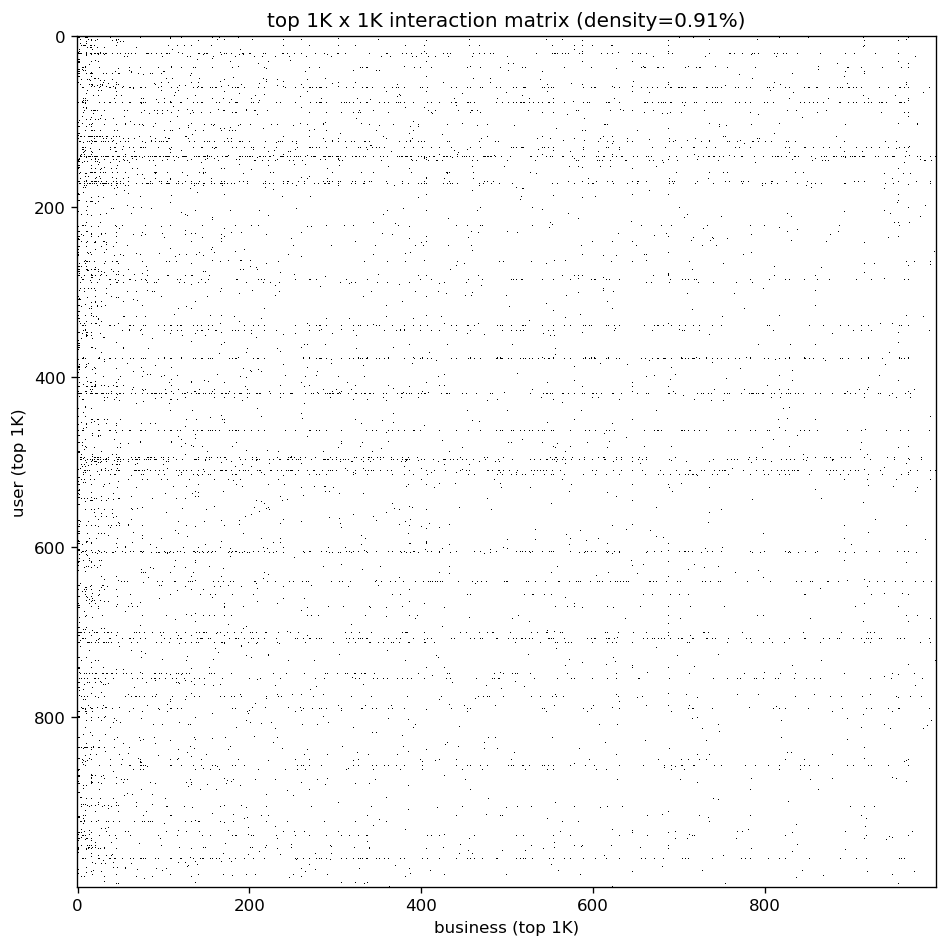

top-1K density: 0.9136%
full matrix density: 0.031864%  (sparsity: 99.9681%)


In [4]:
top_users = users.nlargest(1000, "review_count")["user_id"].values
top_biz = restaurants.nlargest(1000, "review_count")["business_id"].values

sample = reviews[reviews["user_id"].isin(top_users) & reviews["business_id"].isin(top_biz)]
user_idx = {u: i for i, u in enumerate(top_users)}
biz_idx = {b: i for i, b in enumerate(top_biz)}

matrix = np.zeros((1000, 1000), dtype=np.uint8)
for _, r in sample.iterrows():
    matrix[user_idx[r["user_id"]], biz_idx[r["business_id"]]] = 1

density = matrix.sum() / matrix.size

fig, ax = plt.subplots(figsize=(8, 8))
ax.imshow(matrix, aspect="auto", cmap="Greys", interpolation="nearest")
ax.set_xlabel("business (top 1K)")
ax.set_ylabel("user (top 1K)")
ax.set_title(f"top 1K x 1K interaction matrix (density={density*100:.2f}%)")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "eda_q2_sparsity.png", bbox_inches="tight")
plt.show()

full_density = len(reviews) / (len(users) * len(restaurants))
print(f"top-1K density: {density*100:.4f}%")
print(f"full matrix density: {full_density*100:.6f}%  (sparsity: {(1-full_density)*100:.4f}%)")

The full user-item matrix is 99.97% sparse, and even the top-1K densest slice is still under 1% dense. This is severe — pure user-user collaborative filtering is not going to work. The recommendation has to lean on item content (cuisine/category embeddings) and user-side aggregated features rather than direct co-occurrence.

**Q3 — top categories, build a 50-cuisine vocabulary.** Yelp `categories` is a comma-joined string. Counting tokens, dropping the generic top-level labels (`Restaurants`, `Food`, `Nightlife`, `Bars`, `Event Planning & Services`), and taking the top 50 gives the cuisine vocabulary for the multi-hot category feature in Phase 3.

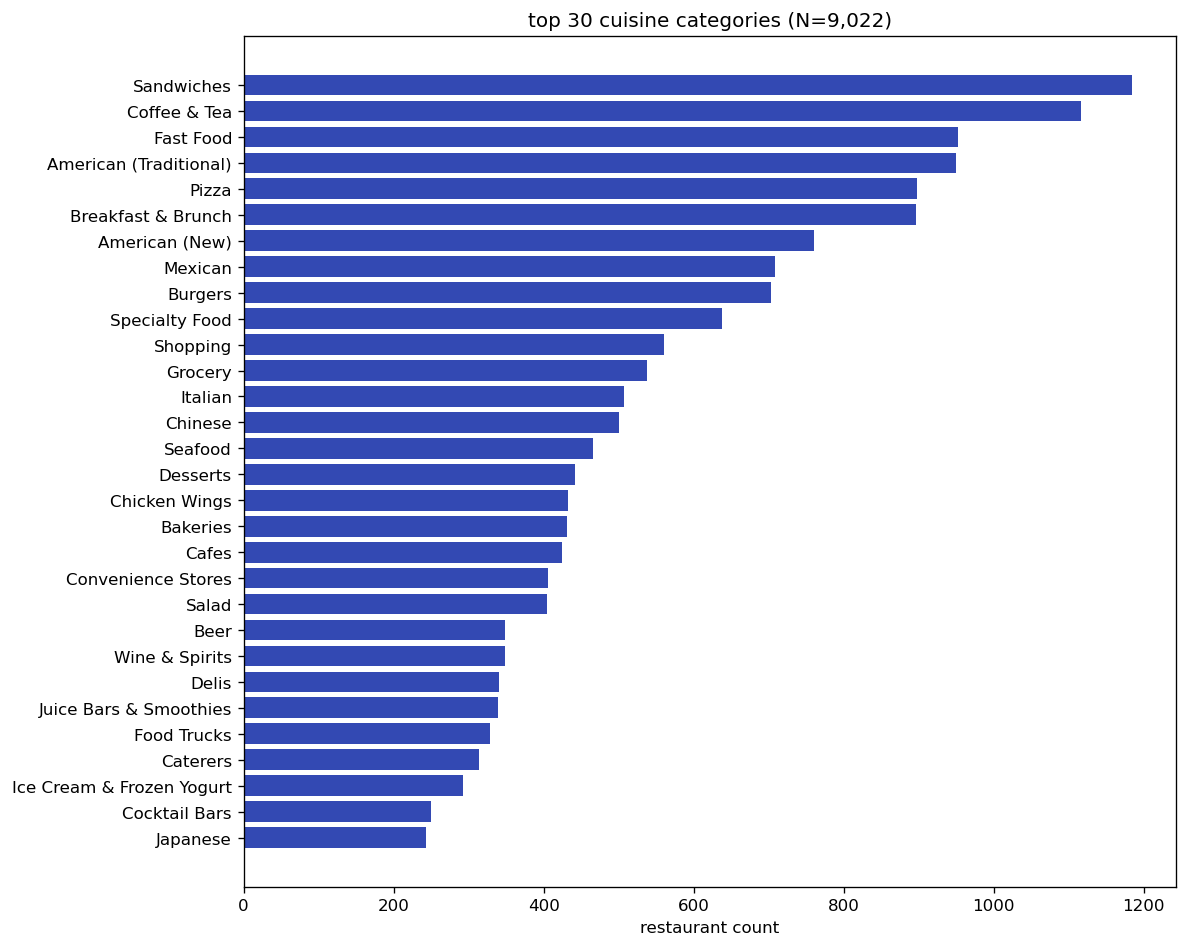

wrote cuisine_vocab.json with 50 cuisines
top 5: ['Sandwiches', 'Coffee & Tea', 'Fast Food', 'American (Traditional)', 'Pizza']


In [5]:
cat_counter = Counter()
for cats_str in restaurants["categories"].dropna():
    for cat in [c.strip() for c in cats_str.split(",")]:
        if cat:
            cat_counter[cat] += 1

EXCLUDE = {"Restaurants", "Food", "Nightlife", "Bars", "Event Planning & Services"}
cuisine_vocab = [c for c, _ in cat_counter.most_common(80) if c not in EXCLUDE][:50]

with open(FEATURES_DIR / "cuisine_vocab.json", "w") as f:
    json.dump({
        "version": "v1.0_2026-05-06",
        "size": len(cuisine_vocab),
        "cuisines": cuisine_vocab,
        "source": "EDA Q3 — top-50 categories from restaurants_open.parquet (excluding generic top-level labels)",
    }, f, indent=2, ensure_ascii=False)

top30 = [(c, cat_counter[c]) for c in cuisine_vocab[:30]]
labels = [c for c, _ in top30]
counts = [n for _, n in top30]

fig, ax = plt.subplots(figsize=(10, 8))
y_pos = np.arange(len(labels))
ax.barh(y_pos, counts, color="#3349B3")
ax.set_yticks(y_pos)
ax.set_yticklabels(labels)
ax.invert_yaxis()
ax.set_xlabel("restaurant count")
ax.set_title(f"top 30 cuisine categories (N={len(restaurants):,})")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "eda_q3_top_categories.png", bbox_inches="tight")
plt.show()

print(f"wrote cuisine_vocab.json with {len(cuisine_vocab)} cuisines")
print(f"top 5: {cuisine_vocab[:5]}")

**Q4 — geographic distribution and k-means cluster count.** I want a region_id feature for context, so I need to know what `k` makes sense for k-means on lat/lon. Plot the 3 cities side by side, then fit k-means on Philadelphia (largest sample) for k=2..11 to find an elbow.

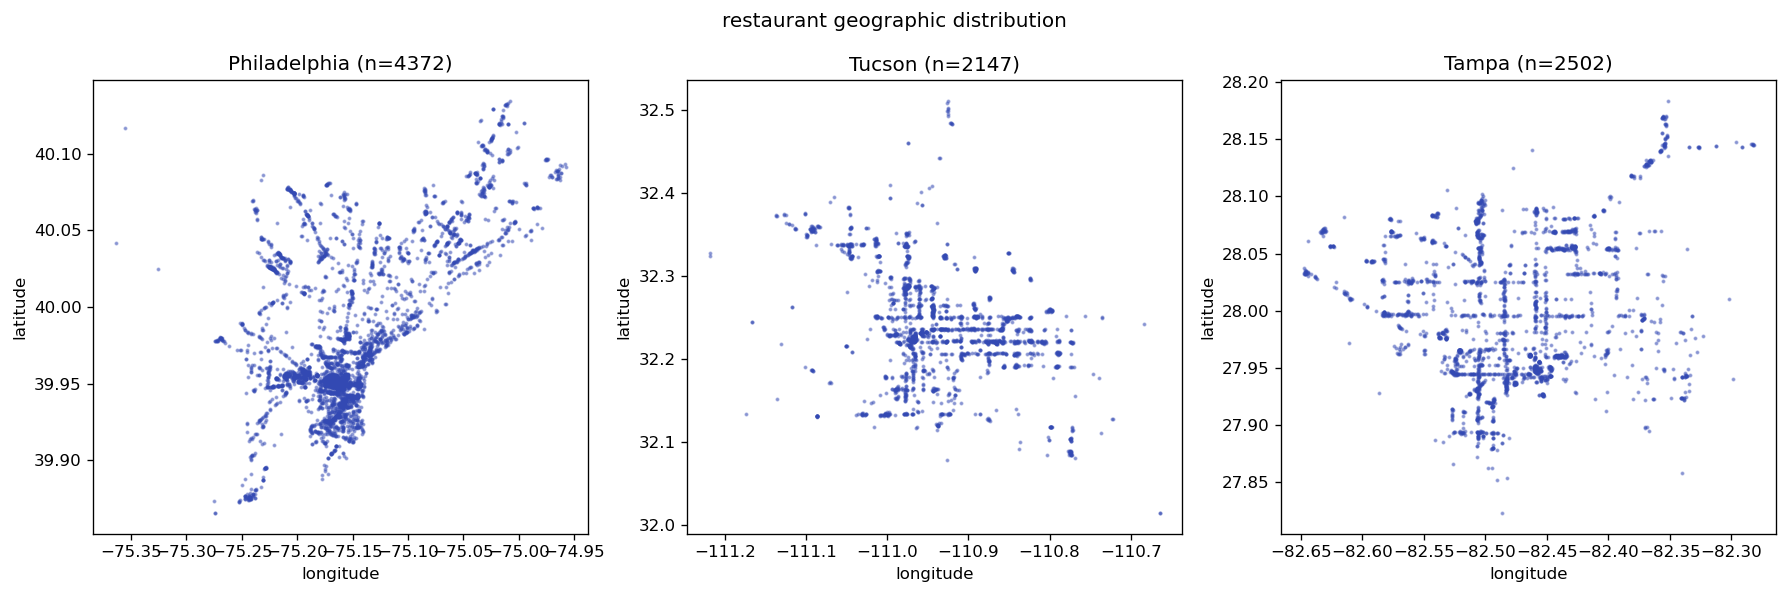

In [6]:
# Q4a — 3-city scatter
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
cities = ["Philadelphia", "Tucson", "Tampa"]
for ax, city in zip(axes, cities):
    sub = restaurants[restaurants["city"] == city]
    ax.scatter(sub["longitude"], sub["latitude"], s=2, alpha=0.4, c="#3349B3")
    ax.set_title(f"{city} (n={len(sub)})")
    ax.set_xlabel("longitude")
    ax.set_ylabel("latitude")
fig.suptitle("restaurant geographic distribution")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "eda_q4_geo.png", bbox_inches="tight")
plt.show()

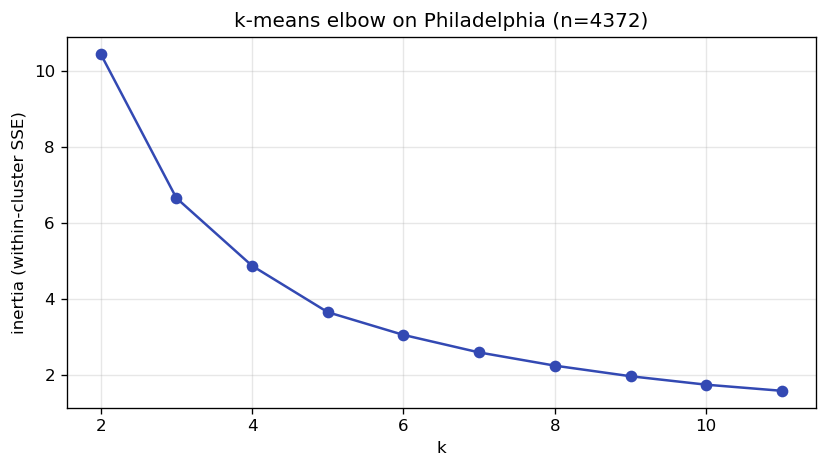

inertia at k=8: 2


In [7]:
# Q4b — k-means elbow on Philadelphia
from sklearn.cluster import KMeans

phi = restaurants[restaurants["city"] == "Philadelphia"][["latitude", "longitude"]].values
inertias = []
ks = list(range(2, 12))
for k in ks:
    km = KMeans(n_clusters=k, n_init=10, random_state=42)
    km.fit(phi)
    inertias.append(km.inertia_)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(ks, inertias, "o-", color="#3349B3")
ax.set_xlabel("k")
ax.set_ylabel("inertia (within-cluster SSE)")
ax.set_title(f"k-means elbow on Philadelphia (n={len(phi)})")
ax.grid(True, alpha=0.3)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "eda_q4_kmeans_elbow.png", bbox_inches="tight")
plt.show()
print(f"inertia at k=8: {inertias[6]:.0f}")

The elbow is around k=8 — inertia drops fast through k=7 and starts flattening after. I'll use k=8 region clusters per city in Phase 3.

**Q5 — review submission hour distribution.** The Yelp dataset has review timestamps but not visit timestamps, so this is at best a weak proxy for engagement timing. Still useful for the `hour_bucket` context feature.

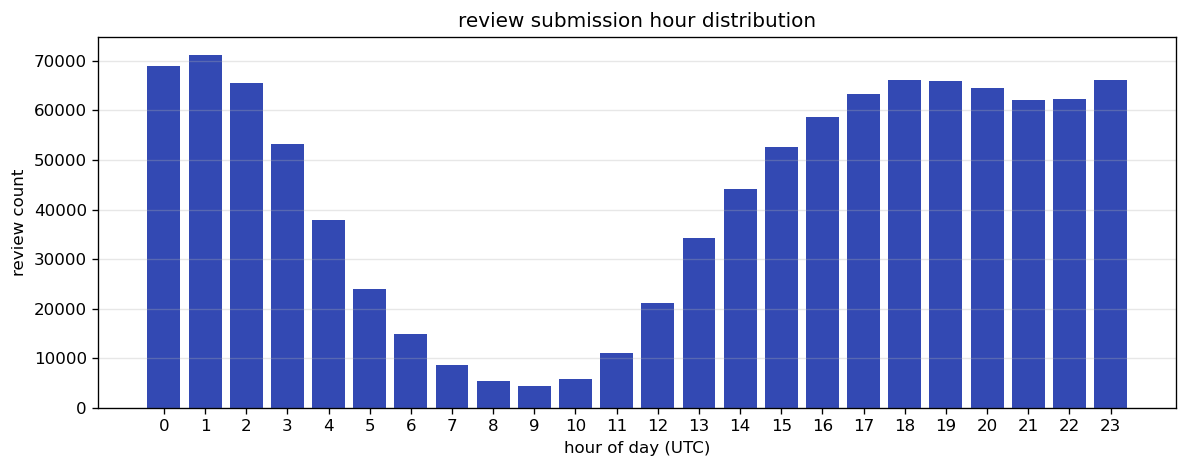

peak hour: 1:00


In [8]:
reviews_q5 = reviews.copy()
reviews_q5["date"] = pd.to_datetime(reviews_q5["date"])
reviews_q5["hour"] = reviews_q5["date"].dt.hour
hour_dist = reviews_q5["hour"].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(hour_dist.index, hour_dist.values, color="#3349B3")
ax.set_xticks(range(24))
ax.set_xlabel("hour of day (UTC)")
ax.set_ylabel("review count")
ax.set_title("review submission hour distribution")
ax.grid(True, axis="y", alpha=0.3)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "eda_q5_hour_dist.png", bbox_inches="tight")
plt.show()
print(f"peak hour: {hour_dist.idxmax()}:00")

Caveat: this is the time the review was *posted*, not the time the user *visited* the restaurant. People often write reviews late at night after the meal. So treating this as direct dining-time signal would be wrong; using it as a coarse engagement-time feature is OK.

**Q6 — cold-start ratio.** What fraction of users and businesses have very few reviews? This bounds how much the model can lean on user/item embeddings vs. content features.

In [9]:
cold_users = (users["review_count"] < 5).sum()
cold_biz = (restaurants["review_count"] < 10).sum()
print(f"cold-start users (review_count<5): {cold_users}/{len(users)} = {cold_users/len(users)*100:.1f}%")
print(f"cold-start businesses (review_count<10): {cold_biz}/{len(restaurants)} = {cold_biz/len(restaurants)*100:.1f}%")

cold-start users (review_count<5): 119156/359007 = 33.2%
cold-start businesses (review_count<10): 1445/9022 = 16.0%


**Q7 — photo coverage.** Yelp's `photos.json` is a separate 5 GB file I haven't downloaded. As a proxy I scan the `attributes` JSON column for any photo-related key. This is a weak estimate — for the demo UI, I'll use placeholder cards.

In [10]:
def has_photo_attr(x):
    return isinstance(x, dict) and any("photo" in str(k).lower() for k in x)

attrs = restaurants.get("attributes", pd.Series([{}]))
has_photos = attrs.apply(has_photo_attr).sum()
print(f"businesses with photo-related attribute: {has_photos}/{len(restaurants)} = {has_photos/len(restaurants)*100:.1f}%")

businesses with photo-related attribute: 0/9022 = 0.0%


**Q8 — review text length distribution.** Sets the input cap for the AI Overview LLM call (Sonnet) — I want to know what P90 review length looks like in characters/tokens so we don't over-pay on context.

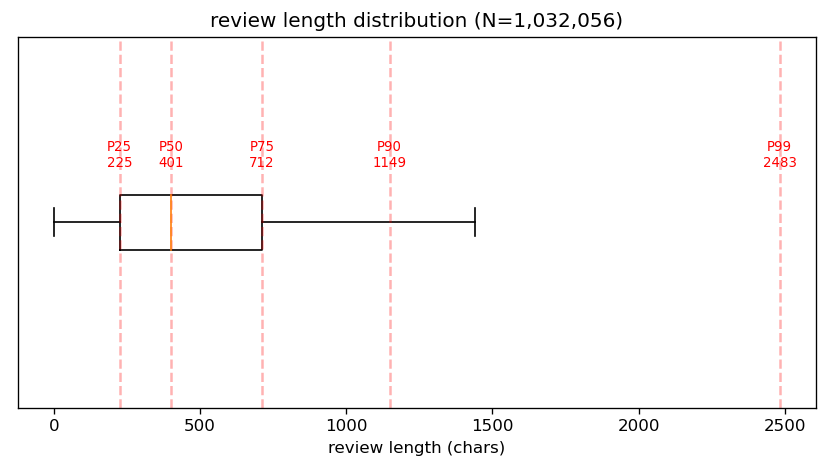

P25: 225 chars (~56 tokens)
P50: 401 chars (~100 tokens)
P75: 712 chars (~178 tokens)
P90: 1149 chars (~287 tokens)
P99: 2483 chars (~620 tokens)


In [11]:
lens = reviews["text"].fillna("").str.len()
pcts = [25, 50, 75, 90, 99]
quants = lens.quantile([p/100 for p in pcts])

fig, ax = plt.subplots(figsize=(7, 4))
ax.boxplot([lens.values], showfliers=False, vert=False)
ax.set_xlabel("review length (chars)")
ax.set_yticks([])
ax.set_title(f"review length distribution (N={len(lens):,})")
for p, q in zip(pcts, quants.values):
    ax.axvline(q, color="red", alpha=0.3, linestyle="--")
    ax.text(q, 1.15, f"P{p}\n{int(q)}", ha="center", fontsize=8, color="red")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "eda_q8_review_length.png", bbox_inches="tight")
plt.show()

for p, q in zip(pcts, quants.values):
    print(f"P{p}: {int(q)} chars (~{int(q/4)} tokens)")

P90 sits around 1,150 chars (~290 tokens). Capping LLM input at P90 means the AI Overview call sees the long reviews as full text and only truncates the rare 99th-percentile outliers.

**Q9 — cross-city user mobility.** Phase 1 already extracted the multi-city subset; here I just print the breakdown to confirm the H8 hypothesis has enough signal to test.

In [12]:
biz_city = restaurants.set_index("business_id")["city"].to_dict()
rev_city = reviews.copy()
rev_city["city"] = rev_city["business_id"].map(biz_city)
user_n_cities = rev_city.groupby("user_id")["city"].nunique()

n_multi = (user_n_cities >= 2).sum()
n_three = (user_n_cities >= 3).sum()
print(f"users in >=2 cities: {n_multi}/{len(users)} = {n_multi/len(users)*100:.2f}%")
print(f"users in all 3 cities: {n_three}/{len(users)} = {n_three/len(users)*100:.3f}%")

users in >=2 cities: 5250/359007 = 1.46%
users in all 3 cities: 160/359007 = 0.045%


**Q10 — popularity bias (Lorenz curve and Gini).** A small fraction of restaurants get most of the reviews. Knowing the Gini sets expectations for the diversity penalty in MMR re-ranking later (Phase 6) — high concentration means popularity priors will dominate the ranker without explicit diversity.

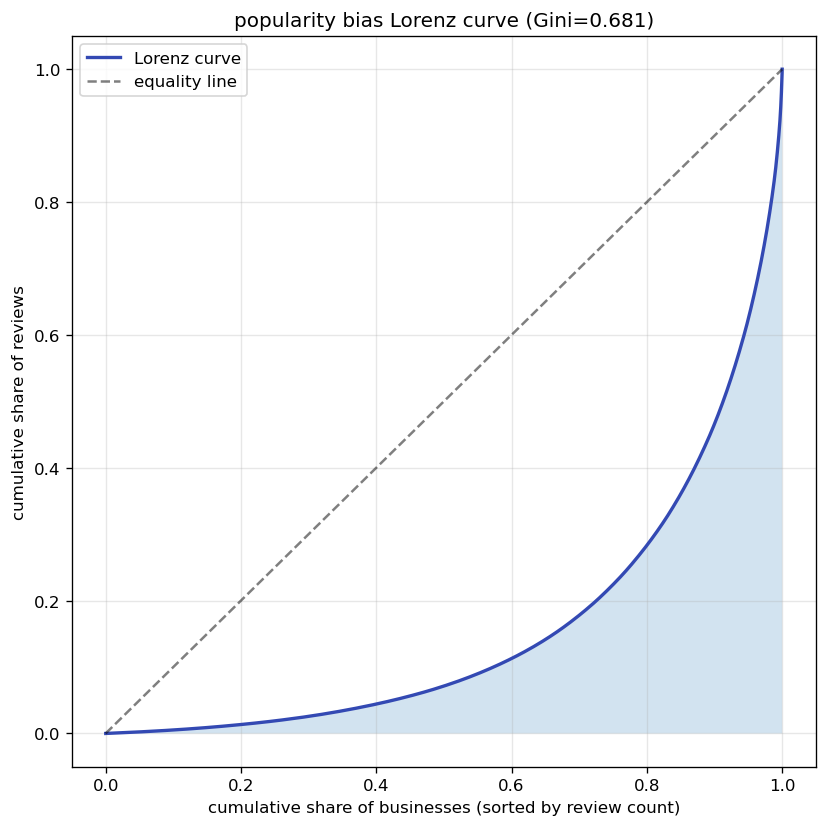

Gini: 0.681
top 1% restaurants get 15.2% of reviews


In [13]:
biz_review_counts = reviews["business_id"].value_counts().sort_values()
rc = biz_review_counts.values
cum_biz = np.arange(1, len(rc)+1) / len(rc)
cum_rev = np.cumsum(rc) / rc.sum()

auc = np.trapz(cum_rev, cum_biz)
gini = 1 - 2 * auc

fig, ax = plt.subplots(figsize=(7, 7))
ax.plot(cum_biz, cum_rev, color="#3349B3", linewidth=2, label="Lorenz curve")
ax.plot([0, 1], [0, 1], color="black", linestyle="--", alpha=0.5, label="equality line")
ax.fill_between(cum_biz, cum_rev, alpha=0.2)
ax.set_xlabel("cumulative share of businesses (sorted by review count)")
ax.set_ylabel("cumulative share of reviews")
ax.set_title(f"popularity bias Lorenz curve (Gini={gini:.3f})")
ax.legend()
ax.grid(True, alpha=0.3)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "eda_q10_lorenz_gini.png", bbox_inches="tight")
plt.show()

top_1pct = int(len(rc) * 0.01)
top_share = rc[-top_1pct:].sum() / rc.sum()
print(f"Gini: {gini:.3f}")
print(f"top 1% restaurants get {top_share*100:.1f}% of reviews")

Gini of 0.68 confirms strong concentration — the top 1% of restaurants get about 15% of reviews. The popular-place bias will pull the ranker towards a few dozen restaurants unless the F2 trip mode uses MMR or a diversity-aware re-rank.

**Q11 — activity text availability.** The F2 trip-planning feature wants natural-language activity descriptions ('walking through Old City', 'Liberty Bell tour'), but the Yelp Open Dataset doesn't have a native activity field. Two paths forward: generate descriptions with Sonnet at demo time (~$0.003 per activity, 27 activities = ~$0.08), or pre-author 30-50 templates per city. Generation is cheaper for the demo scope; templates would be the production fallback if LLM cost grew.

Phase 2 done. cuisine_vocab.json is in `data/features/`, all 9 figures are in `reports/figures/`.